In [9]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D

from keras.datasets import mnist

In [10]:
#load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
#reshape dataset to have a single channel
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)
#normalize pixel values to be between 0 and 1
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255
print('X_train shape:', X_train.shape)
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [11]:
conv_layer1 = Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape)
conv_layer2 = Conv2D(64, kernel_size=(3, 3), activation='relu')
max_pooling_layer = MaxPooling2D(pool_size=(2, 2))
dropout_layer1 = Dropout(0.25)
flatten_layer = Flatten()
dense_layer1 = Dense(128, activation='relu')
dropout_layer2 = Dropout(0.2)
dense_layer2 = Dense(10, activation='relu')
dropout_layer3 = Dropout(0.2)
output_layer = Dense(10, activation='softmax')

model = Sequential()
model.add(conv_layer1)
model.add(conv_layer2)
model.add(max_pooling_layer)
model.add(dropout_layer1)
model.add(flatten_layer)
model.add(dense_layer1)
model.add(dropout_layer2)
model.add(dense_layer2)
model.add(dropout_layer3)
model.add(output_layer)


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

In [14]:
from keras.utils import to_categorical

y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train_cat, batch_size=128, epochs=10, verbose=1,
          validation_data=(X_test, y_test_cat))

score = model.evaluate(X_test, y_test_cat, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.7908 - loss: 0.6088 - val_accuracy: 0.9777 - val_loss: 0.0813
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9292 - loss: 0.2167 - val_accuracy: 0.9821 - val_loss: 0.0654
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9449 - loss: 0.1717 - val_accuracy: 0.9860 - val_loss: 0.0528
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9513 - loss: 0.1510 - val_accuracy: 0.9868 - val_loss: 0.0480
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9542 - loss: 0.1347 - val_accuracy: 0.9866 - val_loss: 0.0553
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9570 - loss: 0.1265 - val_accuracy: 0.9884 - val_loss: 0.0436
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9607 - loss: 0.1153 - val_accuracy: 0.9873 - val_loss: 0.0531
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9620 - loss: 0.1090 - 

In [17]:
train_score = model.evaluate(X_train, y_train_cat, verbose=0)
test_score  = model.evaluate(X_test,  y_test_cat,  verbose=0)

print('Train Accuracy: {:.2f}%'.format(train_score[1] * 100))
print('Test Accuracy:  {:.2f}%'.format(test_score[1]  * 100))

Train Accuracy: 99.65%
Test Accuracy:  99.01%


In [18]:
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)      # predicted labels
y_true = np.argmax(y_test_cat, axis=1)           # true labels

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


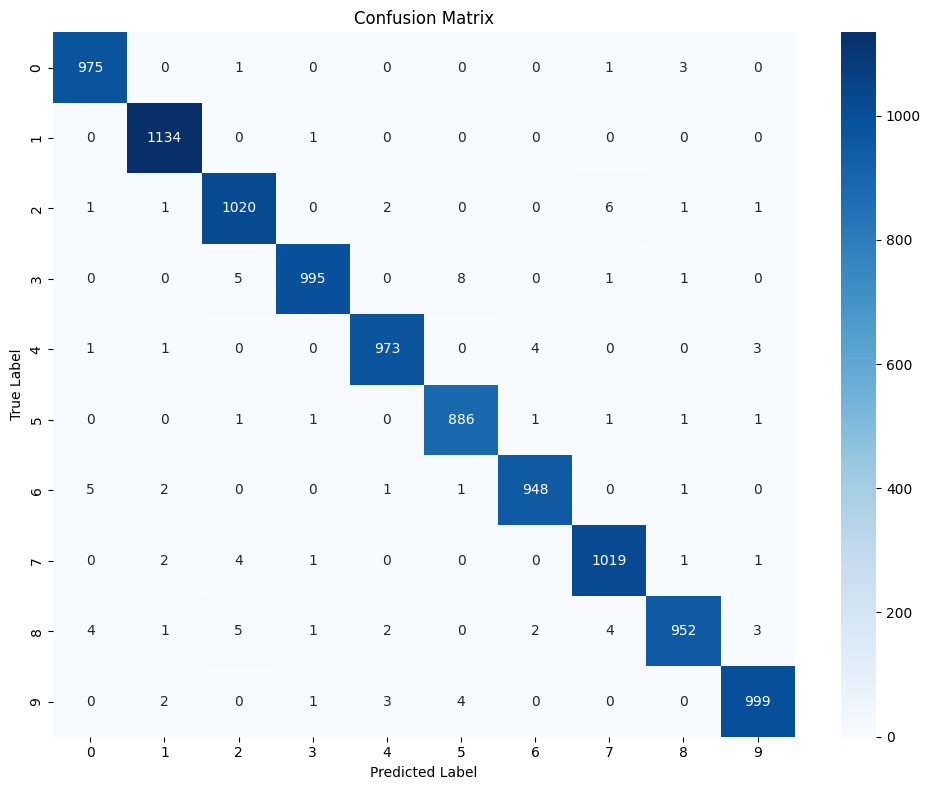

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()